In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [2]:
customers = pd.read_csv("../data/customers.csv")
restaurants = pd.read_csv("../data/restaurants.csv")
orders = pd.read_csv("../data/orders.csv")
sessions = pd.read_csv("../data/sessions.csv")
experiment = pd.read_csv("../data/experiment.csv")

In [3]:
print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Sessions:", sessions.shape)
print("Experiment:", experiment.shape)

Customers: (3000, 4)
Restaurants: (250, 6)
Orders: (12000, 18)
Sessions: (18000, 7)
Experiment: (8000, 10)


In [4]:
orders.head()

,order_id,order_date,customer_id,restaurant_id,city,cuisine,order_value,discount,delivery_fee,net_order_value,delivery_time_min,rating,order_status,payment_method,promo_used,distance_km,is_new_customer,month
0,O000001,2026-04-07,C02517,R0122,Chennai,Healthy,539.0,80,39,459.0,52,3.3,Delivered,Card,True,9.6,False,2026-04
1,O000002,2026-05-01,C01887,R0154,Bengaluru,Burgers,784.0,0,29,784.0,55,4.9,Delivered,Cash,False,7.7,False,2026-05
2,O000003,2026-05-21,C02692,R0168,Bengaluru,Biryani,401.0,20,39,381.0,35,4.0,Delivered,UPI,True,2.5,False,2026-05
3,O000004,2026-03-28,C02729,R0054,Delhi NCR,Biryani,581.0,40,0,541.0,44,4.3,Delivered,Wallet,True,3.1,False,2026-03
4,O000005,2026-04-12,C00955,R0141,Pune,Pizza,503.0,0,19,503.0,32,3.9,Delivered,Card,False,2.6,False,2026-04


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           12000 non-null  object 
 1   order_date         12000 non-null  object 
 2   customer_id        12000 non-null  object 
 3   restaurant_id      12000 non-null  object 
 4   city               12000 non-null  object 
 5   cuisine            12000 non-null  object 
 6   order_value        12000 non-null  float64
 7   discount           12000 non-null  int64  
 8   delivery_fee       12000 non-null  int64  
 9   net_order_value    12000 non-null  float64
 10  delivery_time_min  12000 non-null  int64  
 11  rating             11259 non-null  float64
 12  order_status       12000 non-null  object 
 13  payment_method     12000 non-null  object 
 14  promo_used         12000 non-null  bool   
 15  distance_km        12000 non-null  float64
 16  is_new_customer    120

In [6]:
orders.describe()

,order_value,discount,delivery_fee,net_order_value,delivery_time_min,rating,distance_km
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11259.000000,12000.000000
mean,514.553917,31.905000,23.200167,482.648917,36.650083,4.106342,3.519942
std,201.992490,33.691724,15.749083,204.568488,9.247546,0.476708,2.398051
min,122.000000,0.000000,0.000000,60.000000,18.000000,2.300000,0.000000
25%,371.000000,0.000000,0.000000,338.000000,30.000000,3.800000,1.800000
50%,480.000000,20.000000,29.000000,449.500000,36.000000,4.100000,3.000000
75%,617.000000,60.000000,39.000000,588.000000,43.000000,4.400000,4.700000
max,2158.000000,100.000000,49.000000,2158.000000,75.000000,5.000000,22.100000


### Product KPI'S

In [8]:
#total orders
total_orders=orders["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 12000


In [9]:
#total customers
total_customers=orders["customer_id"].nunique()
print("Total Customers:", total_customers)

Total Customers: 2937


In [10]:
#Gross order value
total_gmv=orders["order_value"].sum()
print("Total GMV: ₹", round(total_gmv, 2))

Total GMV: ₹ 6174647.0


In [11]:
#average order value
aov=total_gmv/total_orders
print("AOV: ₹", round(aov, 2))

AOV: ₹ 514.55


### Visualizations 

In [14]:
city_orders=(orders
    .groupby("city")["order_id"]
     .nunique()
     .sort_values(ascending=False)
)
city_orders

city
Bengaluru    2761
Delhi NCR    2220
Mumbai       2185
Hyderabad    1992
Chennai      1492
Pune         1350
Name: order_id, dtype: int64

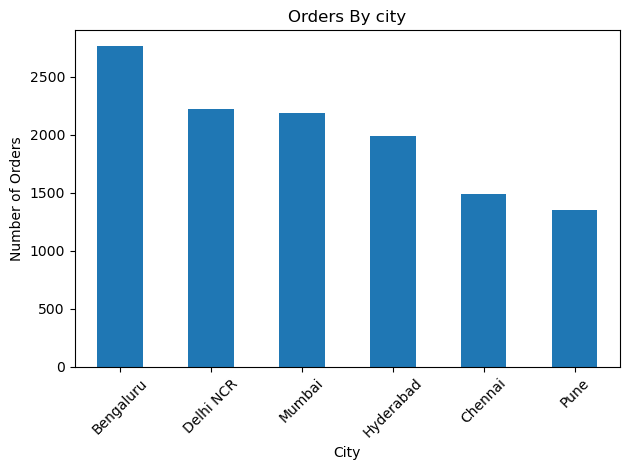

In [15]:
city_orders.plot(kind="bar")
plt.title("Orders By city")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
orders["order_status"].value_counts()

order_status
Delivered    11259
Cancelled      496
Rejected       245
Name: count, dtype: int64

In [17]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
Delivered    93.825000
Cancelled     4.133333
Rejected      2.041667
Name: proportion, dtype: float64

In [18]:
completed_orders=orders[
    orders["order_status"].str.lower()=="delivered"
].copy()

print("Total orders:", len(orders))
print("Completed orders:", len(completed_orders))

Total orders: 12000
Completed orders: 11259


In [19]:
completed_gmv=completed_orders["order_value"].sum()
completed_aov = (
    completed_gmv / completed_orders["order_id"].nunique()
)

print("Completed GMV: ₹", round(completed_gmv, 2))
print("Completed AOV: ₹", round(completed_aov, 2))

Completed GMV: ₹ 5787010.0
Completed AOV: ₹ 513.99


In [21]:
cancellation_rate = (
    (orders["order_status"].str.lower() != "delivered").mean() * 100
)

print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Cancellation Rate: 6.18 %


In [22]:
monthly_kpis = (
    completed_orders
    .groupby("month")
    .agg(
        orders=("order_id", "nunique"),
        gmv=("order_value", "sum"),
        customers=("customer_id", "nunique"),
        avg_delivery_time=("delivery_time_min", "mean"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

monthly_kpis

,month,orders,gmv,customers,avg_delivery_time,avg_rating
0,2026-01,1946,1012963.0,1458,36.781603,4.108582
1,2026-02,1762,906361.0,1333,36.826334,4.107832
2,2026-03,1969,1034818.0,1429,36.614017,4.097105
3,2026-04,1876,955805.0,1383,36.432303,4.105970
4,2026-05,1882,944715.0,1377,36.132837,4.114240
5,2026-06,1824,932348.0,1357,37.084978,4.104715


In [23]:
monthly_kpis["aov"] = (
    monthly_kpis["gmv"] / monthly_kpis["orders"]
)

monthly_kpis

,month,orders,gmv,customers,avg_delivery_time,avg_rating,aov
0,2026-01,1946,1012963.0,1458,36.781603,4.108582,520.535971
1,2026-02,1762,906361.0,1333,36.826334,4.107832,514.393303
2,2026-03,1969,1034818.0,1429,36.614017,4.097105,525.555104
3,2026-04,1876,955805.0,1383,36.432303,4.105970,509.490938
4,2026-05,1882,944715.0,1377,36.132837,4.114240,501.973964
5,2026-06,1824,932348.0,1357,37.084978,4.104715,511.155702


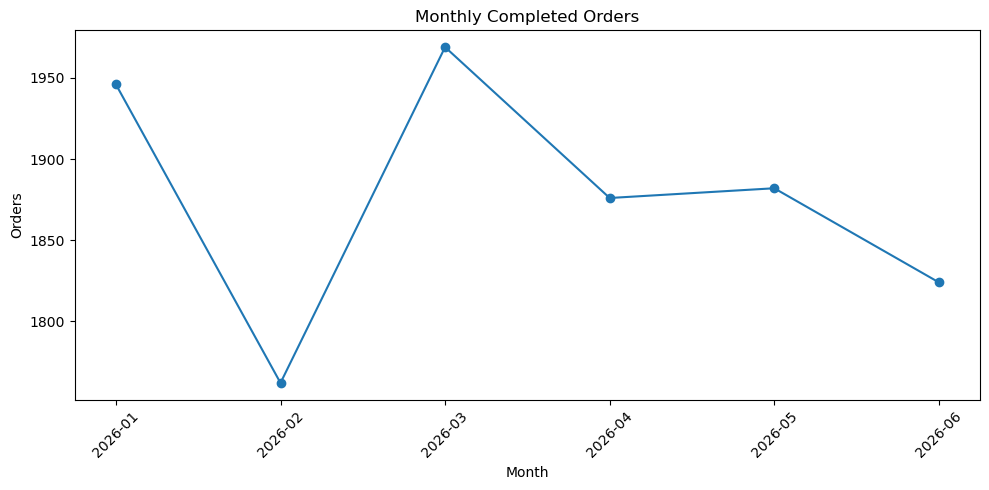

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["orders"],
    marker="o"
)

plt.title("Monthly Completed Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

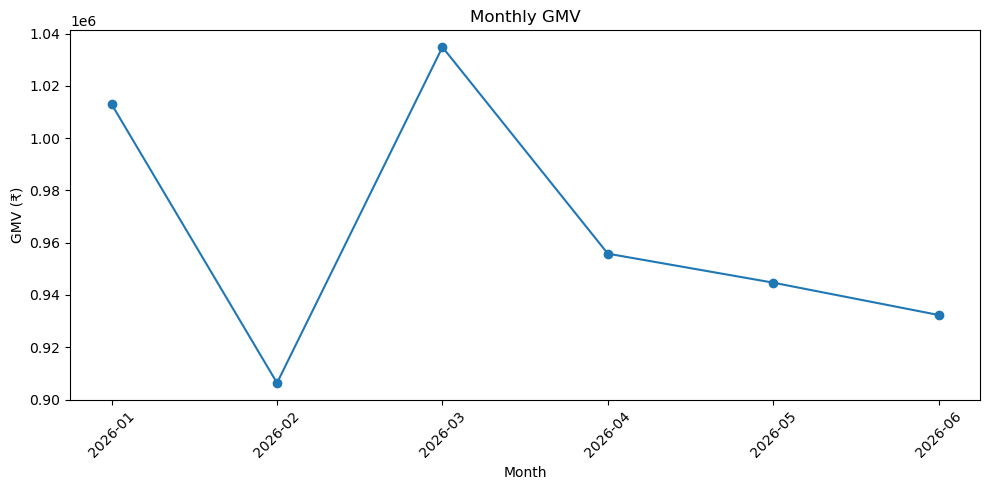

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["gmv"],
    marker="o"
)

plt.title("Monthly GMV")
plt.xlabel("Month")
plt.ylabel("GMV (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Customer Analytics

In [29]:
customer_orders=(
    completed_orders
    .groupby("customer_id")
    .agg(
        orders=("order_id","nunique"),
        total_spend=("order_value","sum"),
        avg_order_value=("order_value","mean")
    )
    .reset_index()
    
    )
customer_orders.head()

,customer_id,orders,total_spend,avg_order_value
0,C00001,3,1349.0,449.666667
1,C00002,3,2038.0,679.333333
2,C00003,2,910.0,455.000000
3,C00004,5,3001.0,600.200000
4,C00005,1,408.0,408.000000


In [30]:
customer_orders["orders"].describe()

count    2924.000000
mean        3.850547
std         1.900509
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: orders, dtype: float64

In [31]:
customer_orders["orders"].value_counts().sort_index()

orders
1     281
2     489
3     610
4     550
5     449
6     282
7     148
8      66
9      32
10     10
11      3
12      4
Name: count, dtype: int64

In [32]:
def frequency_segment(x):
    if x == 1:
        return "One-time"
    elif x <= 3:
        return "Occasional"
    elif x <= 6:
        return "Frequent"
    else:
        return "Very Frequent"

customer_orders["frequency_segment"] = (
    customer_orders["orders"].apply(frequency_segment)
)

In [33]:
customer_orders["frequency_segment"].value_counts()

frequency_segment
Frequent         1281
Occasional       1099
One-time          281
Very Frequent     263
Name: count, dtype: int64

In [35]:
frequency_summary = (
    customer_orders
    .groupby("frequency_segment")
    .agg(
        customers=("customer_id", "nunique"),
        total_orders=("orders", "sum"),
        total_revenue=("total_spend", "sum"),
        avg_customer_spend=("total_spend", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

frequency_summary

,frequency_segment,customers,total_orders,total_revenue,avg_customer_spend
0,Frequent,1281,6137,3152834.0,2461.228728
1,Occasional,1099,2808,1450685.0,1320.004550
2,Very Frequent,263,2033,1040165.0,3955.000000
3,One-time,281,281,143326.0,510.056940


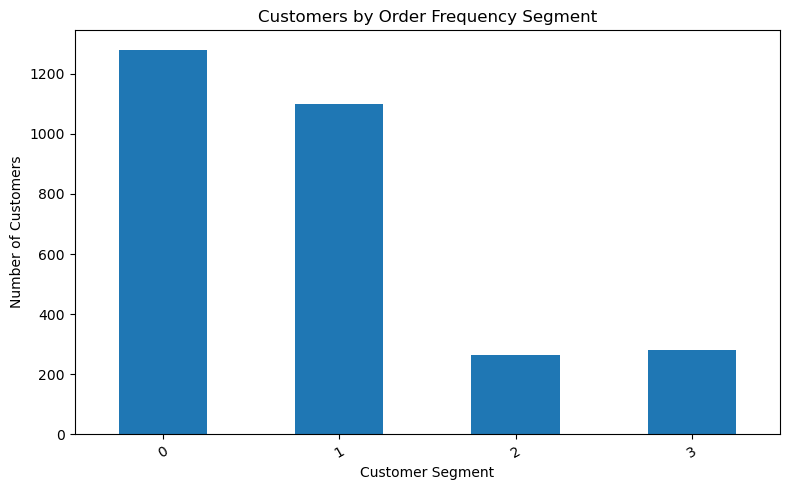

In [36]:
frequency_summary["customers"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customers by Order Frequency Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

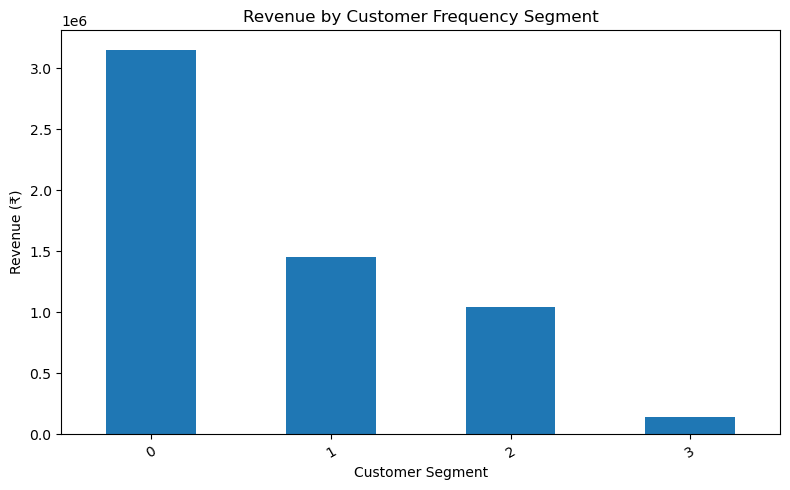

In [37]:
frequency_summary["total_revenue"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Customer Frequency Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### RFM Analysis

In [48]:
#Recency->How recently did customer order?
#Frequently-->How often did they order?
#Monetary-->How much did they spend?

orders["order_date"] = pd.to_datetime(orders["order_date"])



In [49]:
completed_orders["order_date"] = pd.to_datetime(
    completed_orders["order_date"]
)

In [50]:
print(completed_orders["order_date"].dtype)

datetime64[ns]


In [51]:
reference_date = completed_orders["order_date"].max()

print("Reference date:", reference_date)

Reference date: 2026-06-30 00:00:00


In [52]:
rfm = (
    completed_orders
    .groupby("customer_id")
    .agg(
        recency=("order_date", lambda x:
                 (reference_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("order_value", "sum")
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,C00001,8,3,1349.0
1,C00002,37,3,2038.0
2,C00003,133,2,910.0
3,C00004,32,5,3001.0
4,C00005,22,1,408.0


In [53]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [54]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int)
    + rfm["F_score"].astype(int)
    + rfm["M_score"].astype(int)
)

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,C00001,8,3,1349.0,5,2,2,9
1,C00002,37,3,2038.0,3,2,3,8
2,C00003,133,2,910.0,1,1,1,3
3,C00004,32,5,3001.0,3,4,5,12
4,C00005,22,1,408.0,4,1,1,6


In [55]:
def rfm_segment(row):
    score = row["RFM_score"]
    
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Hibernating"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

In [56]:
rfm["segment"].value_counts()

segment
Potential Loyalists    802
Loyal Customers        745
Champions              592
At Risk                409
Hibernating            376
Name: count, dtype: int64

In [57]:
rfm_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

rfm_summary

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
0,Champions,592,12.785473,6.337838,3328.445946,1970440.0
1,Loyal Customers,745,29.260403,4.664430,2436.527517,1815213.0
2,Potential Loyalists,802,41.832918,3.190773,1592.933915,1277533.0
3,At Risk,409,60.777506,2.261614,1115.149144,456096.0
4,Hibernating,376,107.462766,1.457447,712.042553,267728.0


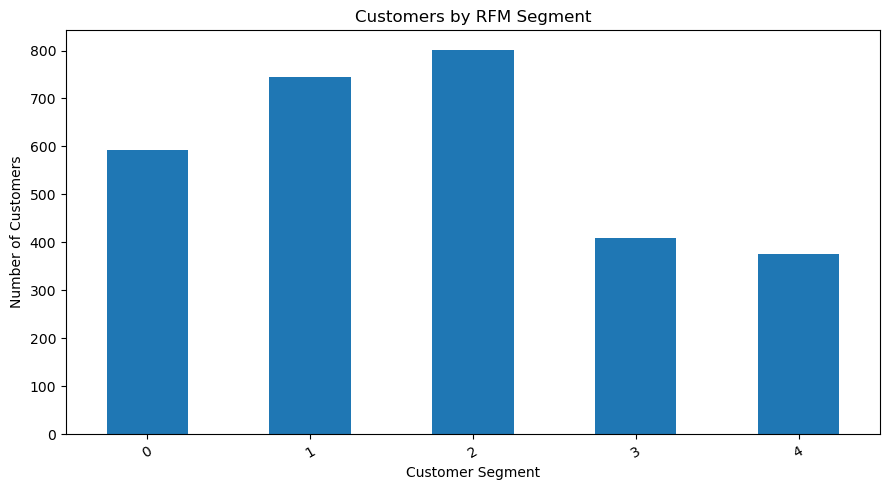

In [58]:
rfm_summary["customers"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

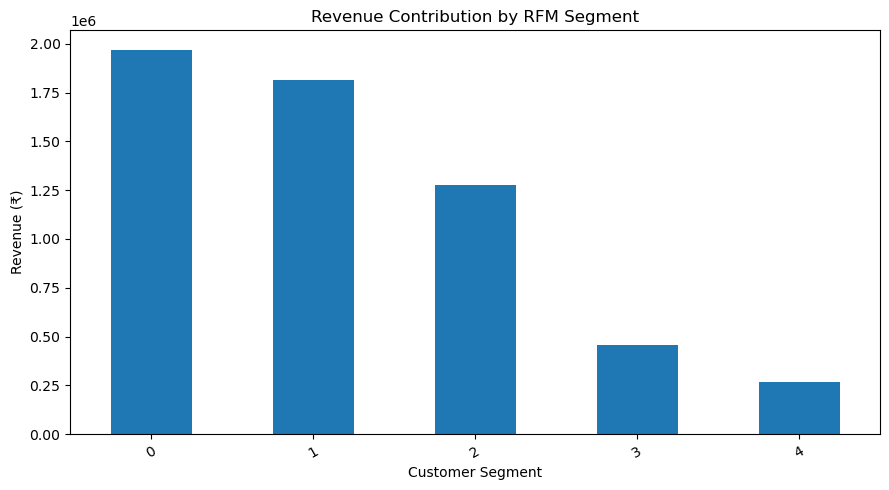

In [59]:
rfm_summary["total_revenue"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Cohort Retention

In [60]:
customer_first_order=(
    completed_orders
    .groupby("customer_id")["order_date"]
    .min()
    .reset_index()
)
customer_first_order.columns=[
    "customer_id",
    "first_order_date"
]
customer_first_order.head()

,customer_id,first_order_date
0,C00001,2026-01-21
1,C00002,2026-02-17
2,C00003,2026-01-09
3,C00004,2026-01-19
4,C00005,2026-06-08


In [61]:
customer_first_order["cohort_month"] = (
    customer_first_order["first_order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

customer_first_order.head()

,customer_id,first_order_date,cohort_month
0,C00001,2026-01-21,2026-01-01
1,C00002,2026-02-17,2026-02-01
2,C00003,2026-01-09,2026-01-01
3,C00004,2026-01-19,2026-01-01
4,C00005,2026-06-08,2026-06-01


In [62]:
cohort_data = completed_orders.merge(
    customer_first_order[
        ["customer_id", "cohort_month"]
    ],
    on="customer_id",
    how="left"
)

cohort_data.head()

,order_id,order_date,customer_id,restaurant_id,city,cuisine,order_value,discount,delivery_fee,net_order_value,delivery_time_min,rating,order_status,payment_method,promo_used,distance_km,is_new_customer,month,cohort_month
0,O000001,2026-04-07,C02517,R0122,Chennai,Healthy,539.0,80,39,459.0,52,3.3,Delivered,Card,True,9.6,False,2026-04,2026-02-01
1,O000002,2026-05-01,C01887,R0154,Bengaluru,Burgers,784.0,0,29,784.0,55,4.9,Delivered,Cash,False,7.7,False,2026-05,2026-01-01
2,O000003,2026-05-21,C02692,R0168,Bengaluru,Biryani,401.0,20,39,381.0,35,4.0,Delivered,UPI,True,2.5,False,2026-05,2026-03-01
3,O000004,2026-03-28,C02729,R0054,Delhi NCR,Biryani,581.0,40,0,541.0,44,4.3,Delivered,Wallet,True,3.1,False,2026-03,2026-01-01
4,O000005,2026-04-12,C00955,R0141,Pune,Pizza,503.0,0,19,503.0,32,3.9,Delivered,Card,False,2.6,False,2026-04,2026-02-01


In [63]:
cohort_data["order_month"] = (
    cohort_data["order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [64]:
cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year -
     cohort_data["cohort_month"].dt.year) * 12
    +
    (cohort_data["order_month"].dt.month -
     cohort_data["cohort_month"].dt.month)
)

In [65]:
cohort_counts = (
    cohort_data
    .groupby(
        ["cohort_month", "cohort_index"]
    )["customer_id"]
    .nunique()
    .reset_index()
)

cohort_counts.head()

,cohort_month,cohort_index,customer_id
0,2026-01-01,0,1458
1,2026-01-01,1,646
2,2026-01-01,2,708
3,2026-01-01,3,689
4,2026-01-01,4,649


In [66]:
cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

cohort_pivot

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2026-01-01,1458.0,646.0,708.0,689.0,649.0,651.0
2026-02-01,687.0,324.0,300.0,328.0,328.0,NaN
2026-03-01,397.0,185.0,181.0,174.0,NaN,NaN
2026-04-01,209.0,109.0,95.0,NaN,NaN,NaN
2026-05-01,110.0,46.0,NaN,NaN,NaN,NaN
2026-06-01,63.0,NaN,NaN,NaN,NaN,NaN


In [67]:
cohort_retention = (
    cohort_pivot
    .div(cohort_pivot[0], axis=0)
    * 100
)

cohort_retention.round(1)

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2026-01-01,100.0,44.3,48.6,47.3,44.5,44.7
2026-02-01,100.0,47.2,43.7,47.7,47.7,NaN
2026-03-01,100.0,46.6,45.6,43.8,NaN,NaN
2026-04-01,100.0,52.2,45.5,NaN,NaN,NaN
2026-05-01,100.0,41.8,NaN,NaN,NaN,NaN
2026-06-01,100.0,NaN,NaN,NaN,NaN,NaN


In [68]:
import seaborn as sns

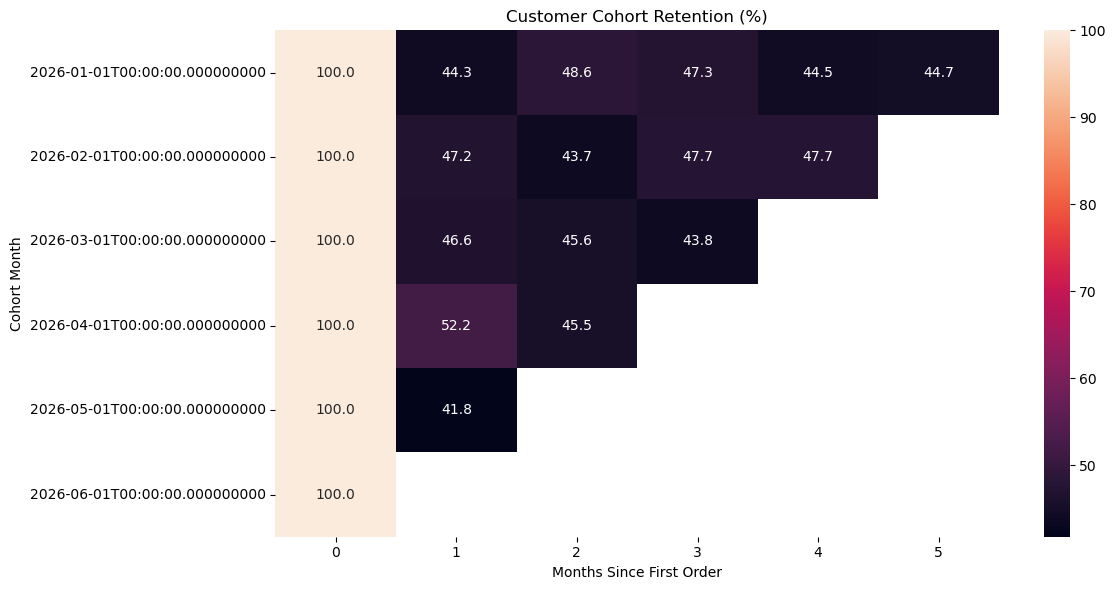

In [69]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cohort_retention.round(1),
    annot=True,
    fmt=".1f"
)

plt.title("Customer Cohort Retention (%)")
plt.xlabel("Months Since First Order")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

In [137]:
# Prepare cohort retention data for Power BI

cohort_retention_long = (
    cohort_retention
    .reset_index()
    .melt(
        id_vars=["cohort_month"],
        var_name="months_since_first_order",
        value_name="retention_rate"
    )
)

cohort_retention_long.head()

,cohort_month,months_since_first_order,retention_rate
0,2026-01-01,0,100.0
1,2026-02-01,0,100.0
2,2026-03-01,0,100.0
3,2026-04-01,0,100.0
4,2026-05-01,0,100.0


In [138]:
cohort_retention_long["months_since_first_order"] = (
    cohort_retention_long["months_since_first_order"].astype(str)
)

In [139]:
cohort_retention_long.to_csv(
    "../powerbi/data/cohort_retention_long.csv",
    index=False
)

print("Cohort Power BI file created!")

Cohort Power BI file created!


### Restaurant & Delivery Analytics

In [70]:
### Restaurant experinece

In [71]:
restaurant_performance = (
    completed_orders
    .groupby("restaurant_id")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        gmv=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        avg_rating=("rating", "mean"),
        avg_delivery_time=("delivery_time_min", "mean")
    )
    .reset_index()
)

restaurant_performance.head()

,restaurant_id,orders,customers,gmv,avg_order_value,avg_rating,avg_delivery_time
0,R0001,41,41,20592.0,502.243902,4.292683,37.487805
1,R0002,39,39,20575.0,527.564103,3.920513,37.230769
2,R0003,47,47,22915.0,487.553191,4.180851,34.234043
3,R0004,40,40,22648.0,566.200000,3.772500,37.250000
4,R0005,56,55,30961.0,552.875000,4.621429,36.285714


In [72]:
top_restaurants = (
    restaurant_performance
    .sort_values("orders", ascending=False)
    .head(10)
)

top_restaurants

,restaurant_id,orders,customers,gmv,avg_order_value,avg_rating,avg_delivery_time
179,R0180,62,62,33259.0,536.435484,4.417742,38.838710
229,R0230,62,61,30900.0,498.387097,4.491935,36.806452
221,R0222,62,61,28147.0,453.983871,4.095161,35.064516
185,R0186,60,59,28941.0,482.350000,4.203333,36.166667
72,R0073,60,60,28656.0,477.600000,4.218333,37.200000
218,R0219,60,59,31037.0,517.283333,4.016667,36.416667
43,R0044,59,59,30725.0,520.762712,4.477966,38.288136
181,R0182,59,59,28488.0,482.847458,4.361017,38.711864
144,R0145,59,57,29166.0,494.338983,3.886441,36.762712
153,R0154,58,58,29291.0,505.017241,4.258621,35.655172


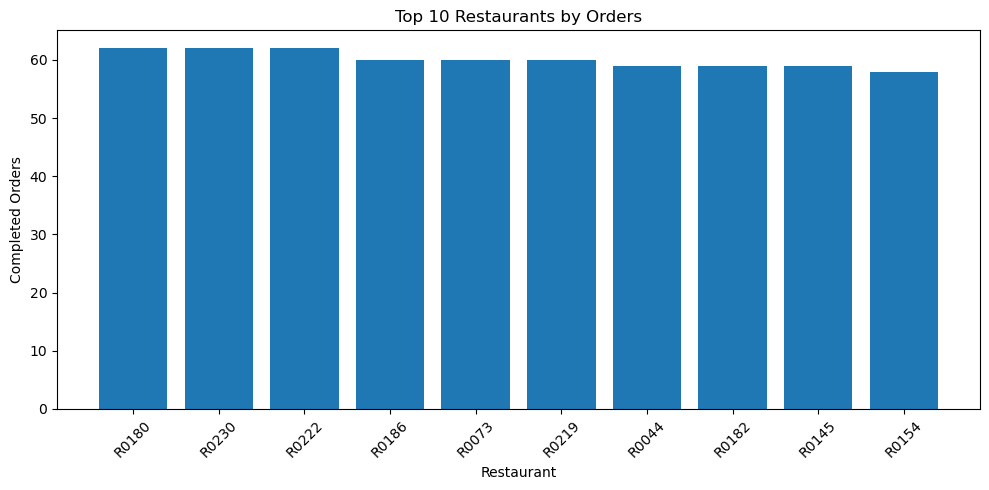

In [73]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_restaurants["restaurant_id"],
    top_restaurants["orders"]
)

plt.title("Top 10 Restaurants by Orders")
plt.xlabel("Restaurant")
plt.ylabel("Completed Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
top_gmv_restaurants = (
    restaurant_performance
    .sort_values("gmv", ascending=False)
    .head(10)
)

top_gmv_restaurants

,restaurant_id,orders,customers,gmv,avg_order_value,avg_rating,avg_delivery_time
179,R0180,62,62,33259.0,536.435484,4.417742,38.838710
154,R0155,55,54,32056.0,582.836364,3.480000,36.654545
89,R0090,55,54,31480.0,572.363636,4.185455,37.509091
218,R0219,60,59,31037.0,517.283333,4.016667,36.416667
4,R0005,56,55,30961.0,552.875000,4.621429,36.285714
229,R0230,62,61,30900.0,498.387097,4.491935,36.806452
43,R0044,59,59,30725.0,520.762712,4.477966,38.288136
152,R0153,58,57,30541.0,526.568966,4.218966,35.362069
63,R0064,56,56,30212.0,539.500000,4.455357,38.142857
114,R0115,58,57,29815.0,514.051724,3.603448,38.448276


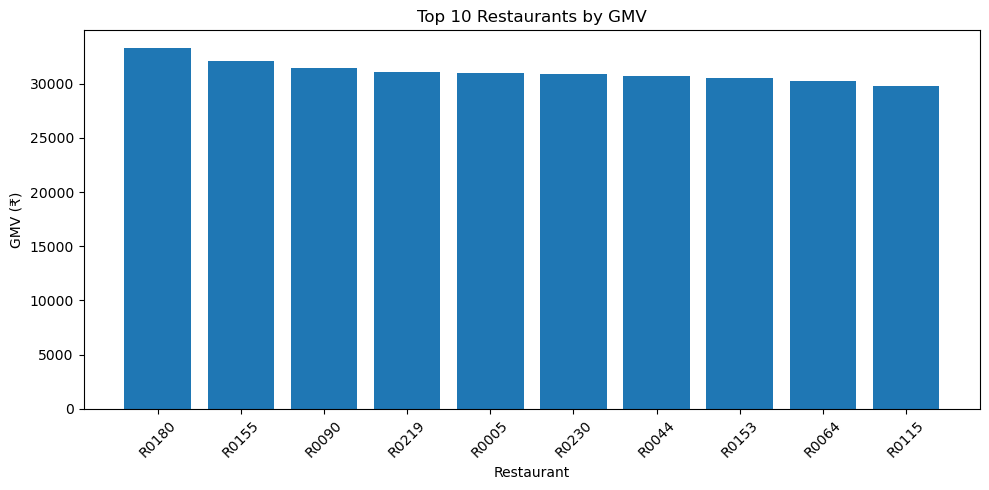

In [75]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_gmv_restaurants["restaurant_id"],
    top_gmv_restaurants["gmv"]
)

plt.title("Top 10 Restaurants by GMV")
plt.xlabel("Restaurant")
plt.ylabel("GMV (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [76]:
city_delivery = (
    completed_orders
    .groupby("city")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_time=("delivery_time_min", "mean"),
        avg_distance=("distance_km", "mean"),
        avg_rating=("rating", "mean")
    )
    .sort_values("avg_delivery_time", ascending=False)
)

city_delivery

,orders,avg_delivery_time,avg_distance,avg_rating
city,,,,
Pune,1253,36.696728,3.400160,4.092338
Chennai,1401,36.694504,3.531406,4.106852
Delhi NCR,2072,36.679054,3.590492,4.118050
Mumbai,2056,36.674125,3.525973,4.093191
Hyderabad,1880,36.645745,3.526223,4.110372
Bengaluru,2597,36.528687,3.522526,4.110974


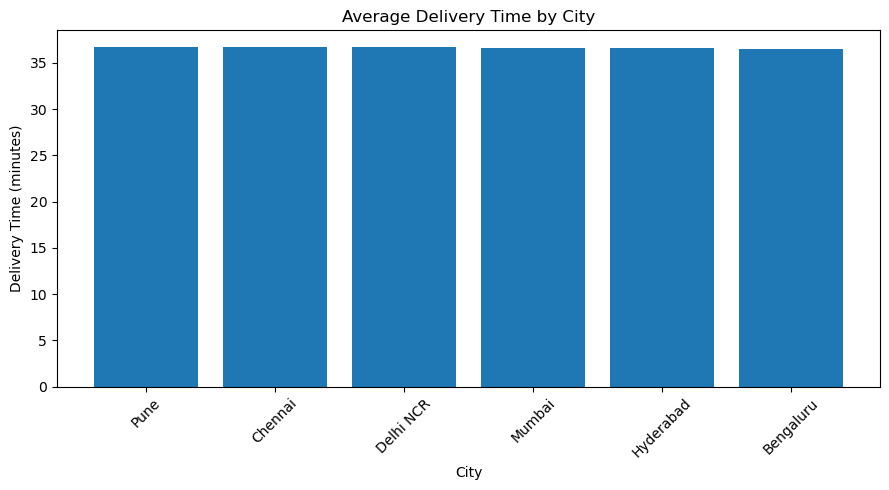

In [77]:
plt.figure(figsize=(9, 5))

plt.bar(
    city_delivery.index,
    city_delivery["avg_delivery_time"]
)

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
delivery_rating = (
    completed_orders
    .dropna(subset=["rating"])
    .groupby(
        pd.cut(
            completed_orders.dropna(subset=["rating"])["delivery_time_min"],
            bins=[0, 25, 35, 45, 60, 100],
            labels=[
                "<25 min",
                "25-35 min",
                "35-45 min",
                "45-60 min",
                "60+ min"
            ]
        )
    )
    .agg(
        avg_rating=("rating", "mean"),
        orders=("order_id", "count")
    )
)

delivery_rating

C:\Users\harika\AppData\Local\Temp\ipykernel_12544\1444465627.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,avg_rating,orders
delivery_time_min,,
<25 min,4.118513,1264
25-35 min,4.108310,4007
35-45 min,4.109874,4132
45-60 min,4.083781,1751
60+ min,4.121905,105


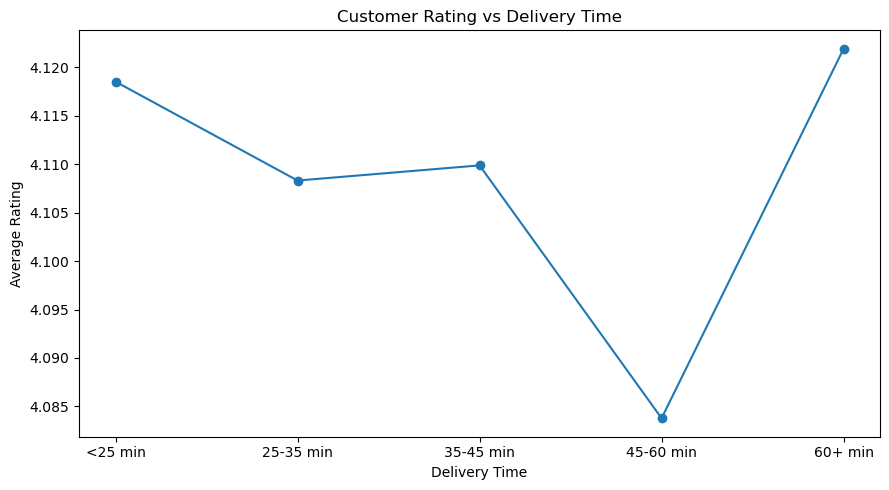

In [79]:
plt.figure(figsize=(9, 5))

plt.plot(
    delivery_rating.index.astype(str),
    delivery_rating["avg_rating"],
    marker="o"
)

plt.title("Customer Rating vs Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [82]:
print(os.path.exists("../zomato_analytics.db"))

False


In [81]:
import os

In [83]:
print(os.getcwd())

E:\zomato_product_analytics_project\notebooks


In [84]:
import sqlite3


db_path = "../zomato_analytics.db"

conn = sqlite3.connect(db_path)

print("Database created at:")
print(os.path.abspath(db_path))
print("\nExists:", os.path.exists(db_path))

Database created at:
E:\zomato_product_analytics_project\zomato_analytics.db

Exists: True


In [85]:
# Load CSV datasets into SQLite database

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

restaurants.to_sql(
    "restaurants",
    conn,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

sessions.to_sql(
    "sessions",
    conn,
    if_exists="replace",
    index=False
)

experiment.to_sql(
    "experiment",
    conn,
    if_exists="replace",
    index=False
)

print("All tables loaded successfully!")

All tables loaded successfully!


In [86]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

pd.read_sql_query(query, conn)

,name
0,customers
1,experiment
2,orders
3,restaurants
4,sessions


In [87]:
tables = ["customers", "restaurants", "orders", "sessions", "experiment"]

for table in tables:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS rows FROM {table}",
        conn
    ).iloc[0]["rows"]
    
    print(f"{table}: {count}")

customers: 3000
restaurants: 250
orders: 12000
sessions: 18000
experiment: 8000


In [88]:
query = """
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS total_customers,
    ROUND(SUM(order_value), 2) AS total_gmv,
    ROUND(AVG(order_value), 2) AS aov
FROM orders
WHERE LOWER(order_status) = 'delivered';
"""

kpi_sql = pd.read_sql_query(query, conn)

kpi_sql

,total_orders,total_customers,total_gmv,aov
0,11259,2924,5787010.0,513.99


### SQL Analysis

In [91]:
#1 Monthly performance
query="""
SELECT
month,
COUNT(DISTINCT order_id) AS delivered_orders,
COUNT(DISTINCT customer_id) AS customers,
ROUND(SUM(order_value),2) AS gmv,
ROUND(AVG(order_value),2) AS aov
FROM orders
WHERE LOWER(order_status)='delivered'
GROUP BY month
ORDER BY month;
"""
monthly_sql=pd.read_sql_query(query,conn)
monthly_sql

,month,delivered_orders,customers,gmv,aov
0,2026-01,1946,1458,1012963.0,520.54
1,2026-02,1762,1333,906361.0,514.39
2,2026-03,1969,1429,1034818.0,525.56
3,2026-04,1876,1383,955805.0,509.49
4,2026-05,1882,1377,944715.0,501.97
5,2026-06,1824,1357,932348.0,511.16


In [90]:
#2 city performance
query="""
SELECT
city,
COUNT(DISTINCT order_id) AS delivered_customers,
COUNT(DISTINCT customer_id) AS customers,
ROUND(SUM(order_value),2) AS gmv,
ROUND(AVG(order_value),2) As aov,
ROUND(AVG(delivery_time_min),2) AS avg_delivery_time,
ROUND(AVG(rating),2) AS avg_rating
FROM orders
WHERE LOWER(order_status)='delivered'
GROUP BY city
ORDER BY gmv DESC;
"""
city_sql=pd.read_sql_query(query,conn)
city_sql

,city,delivered_customers,customers,gmv,aov,avg_delivery_time,avg_rating
0,Bengaluru,2597,806,1350931.0,520.19,36.53,4.11
1,Delhi NCR,2072,656,1062703.0,512.89,36.68,4.12
2,Mumbai,2056,638,1056011.0,513.62,36.67,4.09
3,Hyderabad,1880,614,972050.0,517.05,36.65,4.11
4,Chennai,1401,440,722087.0,515.41,36.69,4.11
5,Pune,1253,411,623228.0,497.39,36.70,4.09


In [92]:
#3 customer order frequncy
query = """
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(order_value), 2) AS total_spend,
    ROUND(AVG(order_value), 2) AS avg_order_value
FROM orders
WHERE LOWER(order_status) = 'delivered'
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 20;
"""

top_customers_sql = pd.read_sql_query(query, conn)

top_customers_sql

,customer_id,total_orders,total_spend,avg_order_value
0,C02839,12,7392.0,616.00
1,C02816,12,6981.0,581.75
2,C02391,12,5744.0,478.67
3,C01061,12,5206.0,433.83
4,C02576,11,6600.0,600.00
5,C02415,11,6415.0,583.18
6,C01605,11,5552.0,504.73
7,C02963,10,5088.0,508.80
8,C02399,10,5121.0,512.10
9,C02135,10,5015.0,501.50


In [93]:
#4 top restaurants
query = """
SELECT
    restaurant_id,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(SUM(order_value), 2) AS gmv,
    ROUND(AVG(order_value), 2) AS aov,
    ROUND(AVG(rating), 2) AS avg_rating
FROM orders
WHERE LOWER(order_status) = 'delivered'
GROUP BY restaurant_id
ORDER BY gmv DESC
LIMIT 10;
"""

top_restaurants_sql = pd.read_sql_query(query, conn)

top_restaurants_sql

,restaurant_id,orders,customers,gmv,aov,avg_rating
0,R0180,62,62,33259.0,536.44,4.42
1,R0155,55,54,32056.0,582.84,3.48
2,R0090,55,54,31480.0,572.36,4.19
3,R0219,60,59,31037.0,517.28,4.02
4,R0005,56,55,30961.0,552.88,4.62
5,R0230,62,61,30900.0,498.39,4.49
6,R0044,59,59,30725.0,520.76,4.48
7,R0153,58,57,30541.0,526.57,4.22
8,R0064,56,56,30212.0,539.50,4.46
9,R0115,58,57,29815.0,514.05,3.60


In [94]:
# high volume+low rated restaurants
query = """
SELECT
    restaurant_id,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(order_value), 2) AS gmv,
    ROUND(AVG(rating), 2) AS avg_rating,
    ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time
FROM orders
WHERE LOWER(order_status) = 'delivered'
GROUP BY restaurant_id
HAVING COUNT(DISTINCT order_id) >= 40
   AND AVG(rating) < 3.8
ORDER BY orders DESC;
"""

risk_restaurants_sql = pd.read_sql_query(query, conn)

risk_restaurants_sql

,restaurant_id,orders,gmv,avg_rating,avg_delivery_time
0,R0115,58,29815.0,3.60,38.45
1,R0220,57,28876.0,3.70,37.74
2,R0155,55,32056.0,3.48,36.65
3,R0240,54,28741.0,3.67,37.89
4,R0197,54,27799.0,3.32,35.54
5,R0187,53,26394.0,3.65,36.06
6,R0169,53,25556.0,3.65,38.42
7,R0026,52,25948.0,3.48,36.13
8,R0083,51,25505.0,3.62,38.16
9,R0077,50,26041.0,3.75,36.60


In [95]:
#city non-delivery rate
query = """
SELECT
    city,
    COUNT(*) AS total_orders,

    SUM(
        CASE
            WHEN LOWER(order_status) != 'delivered'
            THEN 1
            ELSE 0
        END
    ) AS failed_orders,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN LOWER(order_status) != 'delivered'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS non_delivery_rate

FROM orders
GROUP BY city
ORDER BY non_delivery_rate DESC;
"""

city_failure_sql = pd.read_sql_query(query, conn)

city_failure_sql

,city,total_orders,failed_orders,non_delivery_rate
0,Pune,1350,97,7.19
1,Delhi NCR,2220,148,6.67
2,Chennai,1492,91,6.10
3,Bengaluru,2761,164,5.94
4,Mumbai,2185,129,5.90
5,Hyderabad,1992,112,5.62


In [96]:
#7 promo vs non promo behaviuor
query = """
SELECT
    promo_used,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(AVG(order_value), 2) AS aov,
    ROUND(AVG(delivery_time_min), 2) AS avg_delivery_time,
    ROUND(AVG(rating), 2) AS avg_rating
FROM orders
WHERE LOWER(order_status) = 'delivered'
GROUP BY promo_used;
"""

promo_sql = pd.read_sql_query(query, conn)

promo_sql

,promo_used,orders,customers,aov,avg_delivery_time,avg_rating
0,0,4746,2348,512.64,36.76,4.11
1,1,6513,2648,514.97,36.56,4.10


In [97]:
#8 customer life style value
query = """
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(order_value), 2) AS total_gmv,
    ROUND(AVG(order_value), 2) AS aov
FROM orders
WHERE LOWER(order_status) = 'delivered'
GROUP BY customer_id
ORDER BY total_gmv DESC
LIMIT 20;
"""

customer_value_sql = pd.read_sql_query(query, conn)

customer_value_sql

,customer_id,orders,total_gmv,aov
0,C02839,12,7392.0,616.00
1,C02816,12,6981.0,581.75
2,C02576,11,6600.0,600.00
3,C02415,11,6415.0,583.18
4,C01295,9,6167.0,685.22
5,C00111,9,6126.0,680.67
6,C01730,9,5990.0,665.56
7,C00066,8,5748.0,718.50
8,C02391,12,5744.0,478.67
9,C02083,8,5736.0,717.00


### A/B testing

In [98]:
## Should Zomato introducs a free delivery incentive to increase food-order conversion

In [99]:
# ==========================================
# A/B EXPERIMENT ANALYSIS
# ==========================================

In [100]:
experiment.head()

,exposure_id,exposure_date,customer_id,variant,eligible,converted,order_value,promo_cost,delivery_time_min,rating
0,E000001,2026-02-08,C01810,Control,1,0,0.000000,0.0,NaN,NaN
1,E000002,2026-02-02,C00398,Treatment,1,0,0.000000,0.0,NaN,NaN
2,E000003,2026-01-29,C01618,Control,1,1,285.820783,0.0,24.182109,3.732302
3,E000004,2026-02-11,C01461,Control,1,0,0.000000,0.0,NaN,NaN
4,E000005,2026-02-17,C00224,Treatment,1,0,0.000000,0.0,NaN,NaN


In [101]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   exposure_id        8000 non-null   object 
 1   exposure_date      8000 non-null   object 
 2   customer_id        8000 non-null   object 
 3   variant            8000 non-null   object 
 4   eligible           8000 non-null   int64  
 5   converted          8000 non-null   int64  
 6   order_value        8000 non-null   float64
 7   promo_cost         8000 non-null   float64
 8   delivery_time_min  1218 non-null   float64
 9   rating             1218 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 625.1+ KB


In [102]:
experiment.columns

Index(['exposure_id', 'exposure_date', 'customer_id', 'variant', 'eligible',
       'converted', 'order_value', 'promo_cost', 'delivery_time_min',
       'rating'],
      dtype='object')

In [103]:
experiment["variant"].value_counts()

variant
Treatment    4019
Control      3981
Name: count, dtype: int64

In [104]:
experiment["eligible"].value_counts()

eligible
1    6806
0    1194
Name: count, dtype: int64

In [105]:
pd.crosstab(
    experiment["variant"],
    experiment["eligible"]
)

eligible,0,1
variant,,
Control,586,3395
Treatment,608,3411


In [106]:
pd.crosstab(
    experiment["variant"],
    experiment["converted"]
)

converted,0,1
variant,,
Control,3407,574
Treatment,3375,644


In [107]:
conversion_summary = (
    experiment
    .groupby("variant")
    .agg(
        users=("exposure_id", "nunique"),
        conversions=("converted", "sum")
    )
)

conversion_summary["conversion_rate"] = (
    conversion_summary["conversions"]
    / conversion_summary["users"]
    * 100
)

conversion_summary

,users,conversions,conversion_rate
variant,,,
Control,3981,574,14.418488
Treatment,4019,644,16.023887


In [108]:
control_rate = conversion_summary.loc[
    "Control", "conversion_rate"
]

treatment_rate = conversion_summary.loc[
    "Treatment", "conversion_rate"
]

absolute_lift = treatment_rate - control_rate

relative_lift = (
    (treatment_rate - control_rate)
    / control_rate
    * 100
)

print("Control conversion:", round(control_rate, 2), "%")
print("Treatment conversion:", round(treatment_rate, 2), "%")
print("Absolute lift:", round(absolute_lift, 2), "percentage points")
print("Relative lift:", round(relative_lift, 2), "%")

Control conversion: 14.42 %
Treatment conversion: 16.02 %
Absolute lift: 1.61 percentage points
Relative lift: 11.13 %


In [110]:
experiment_summary=(experiment.groupby("variant").agg(
    users=("exposure_id", "nunique"),
    conversions=("converted", "sum"),
    avg_order_value=("order_value", "mean"),
    total_order_value=("order_value", "sum"),
    total_promo_cost=("promo_cost", "sum"),
    avg_promo_cost=("promo_cost", "mean")
)
                   )
experiment_summary

,users,conversions,avg_order_value,total_order_value,total_promo_cost,avg_promo_cost
variant,,,,,,
Control,3981,574,74.025491,294695.478017,1955.952842,0.491322
Treatment,4019,644,84.152451,338208.701046,33559.325450,8.350168


In [111]:
experiment_summary["gmv_per_user"] = (
    experiment_summary["total_order_value"]
    / experiment_summary["users"]
)

In [112]:
experiment_summary["promo_cost_per_user"] = (
    experiment_summary["total_promo_cost"]
    / experiment_summary["users"]
)

In [113]:
experiment_summary

,users,conversions,avg_order_value,total_order_value,total_promo_cost,avg_promo_cost,gmv_per_user,promo_cost_per_user
variant,,,,,,,,
Control,3981,574,74.025491,294695.478017,1955.952842,0.491322,74.025491,0.491322
Treatment,4019,644,84.152451,338208.701046,33559.325450,8.350168,84.152451,8.350168


In [115]:
experiment_summary["net_value"] = (
    experiment_summary["total_order_value"]
    - experiment_summary["total_promo_cost"]
)
experiment_summary["net_value_per_user"] = (
    experiment_summary["net_value"]
    / experiment_summary["users"]
)

experiment_summary

,users,conversions,avg_order_value,total_order_value,total_promo_cost,avg_promo_cost,gmv_per_user,promo_cost_per_user,net_value,net_value_per_user
variant,,,,,,,,,,
Control,3981,574,74.025491,294695.478017,1955.952842,0.491322,74.025491,0.491322,292739.525175,73.534169
Treatment,4019,644,84.152451,338208.701046,33559.325450,8.350168,84.152451,8.350168,304649.375596,75.802283


In [116]:
## Could the obersrved conversion difference simply be random

In [119]:
from statsmodels.stats.proportion import proportions_ztest

In [121]:
conversions = conversion_summary["conversions"].values
users = conversion_summary["users"].values

z_stat, p_value = proportions_ztest(
    conversions,
    users
)

print("Z-statistic:", round(z_stat, 3))
print("P-value:", round(p_value, 4))

Z-statistic: -1.998
P-value: 0.0457


In [122]:
# checking guardrils
guardrails = (
    experiment
    .groupby("variant")
    .agg(
        avg_delivery_time=("delivery_time_min", "mean"),
        avg_rating=("rating", "mean"),
        avg_promo_cost=("promo_cost", "mean")
    )
)

guardrails

,avg_delivery_time,avg_rating,avg_promo_cost
variant,,,
Control,30.623999,4.166364,0.491322
Treatment,30.742154,4.153709,8.350168


In [123]:
experiment.groupby("variant").agg(
    delivery_observations=("delivery_time_min", "count"),
    rating_observations=("rating", "count")
)

,delivery_observations,rating_observations
variant,,
Control,574,574
Treatment,644,644


In [124]:
experiment_summary

,users,conversions,avg_order_value,total_order_value,total_promo_cost,avg_promo_cost,gmv_per_user,promo_cost_per_user,net_value,net_value_per_user
variant,,,,,,,,,,
Control,3981,574,74.025491,294695.478017,1955.952842,0.491322,74.025491,0.491322,292739.525175,73.534169
Treatment,4019,644,84.152451,338208.701046,33559.325450,8.350168,84.152451,8.350168,304649.375596,75.802283


In [125]:
eligible_experiment = experiment[
    experiment["eligible"] == 1
].copy()

In [130]:
eligible_experiment

,exposure_id,exposure_date,customer_id,variant,eligible,converted,order_value,promo_cost,delivery_time_min,rating
0,E000001,2026-02-08,C01810,Control,1,0,0.000000,0.000000,NaN,NaN
1,E000002,2026-02-02,C00398,Treatment,1,0,0.000000,0.000000,NaN,NaN
2,E000003,2026-01-29,C01618,Control,1,1,285.820783,0.000000,24.182109,3.732302
3,E000004,2026-02-11,C01461,Control,1,0,0.000000,0.000000,NaN,NaN
4,E000005,2026-02-17,C00224,Treatment,1,0,0.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7994,E007995,2026-01-22,C02965,Control,1,0,0.000000,0.000000,NaN,NaN
7995,E007996,2026-02-13,C00201,Treatment,1,1,357.320862,46.767306,31.462084,4.722881
7996,E007997,2026-01-27,C02674,Control,1,0,0.000000,0.000000,NaN,NaN
7997,E007998,2026-01-30,C02636,Treatment,1,0,0.000000,0.000000,NaN,NaN


In [131]:
eligible_summary = (
    eligible_experiment
    .groupby("variant")
    .agg(
        users=("exposure_id", "nunique"),
        conversions=("converted", "sum"),
        total_order_value=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        total_promo_cost=("promo_cost", "sum"),
        avg_promo_cost=("promo_cost", "mean")
    )
)

eligible_summary["conversion_rate"] = (
    eligible_summary["conversions"]
    / eligible_summary["users"]
    * 100
)

eligible_summary["gmv_per_user"] = (
    eligible_summary["total_order_value"]
    / eligible_summary["users"]
)

eligible_summary["net_value"] = (
    eligible_summary["total_order_value"]
    - eligible_summary["total_promo_cost"]
)

eligible_summary["net_value_per_user"] = (
    eligible_summary["net_value"]
    / eligible_summary["users"]
)
eligible_summary["promo_cost_per_user"] = (
    eligible_summary["total_promo_cost"]
    / eligible_summary["users"]
)

eligible_summary

,users,conversions,total_order_value,avg_order_value,total_promo_cost,avg_promo_cost,conversion_rate,gmv_per_user,net_value,net_value_per_user,promo_cost_per_user
variant,,,,,,,,,,,
Control,3395,549,281831.362435,83.013656,1888.857323,0.556364,16.170839,83.013656,279942.505112,82.457292,0.556364
Treatment,3411,617,324939.368607,95.262201,32161.492889,9.428758,18.088537,95.262201,292777.875718,85.833443,9.428758


In [127]:
control_rate = eligible_summary.loc[
    "Control", "conversion_rate"
]

treatment_rate = eligible_summary.loc[
    "Treatment", "conversion_rate"
]

absolute_lift = treatment_rate - control_rate

relative_lift = (
    absolute_lift / control_rate
) * 100

print("Control conversion:", round(control_rate, 2), "%")
print("Treatment conversion:", round(treatment_rate, 2), "%")
print("Absolute lift:", round(absolute_lift, 2), "percentage points")
print("Relative lift:", round(relative_lift, 2), "%")

Control conversion: 16.17 %
Treatment conversion: 18.09 %
Absolute lift: 1.92 percentage points
Relative lift: 11.86 %


In [128]:
from statsmodels.stats.proportion import proportions_ztest

conversions = [
    eligible_summary.loc["Control", "conversions"],
    eligible_summary.loc["Treatment", "conversions"]
]

users = [
    eligible_summary.loc["Control", "users"],
    eligible_summary.loc["Treatment", "users"]
]

z_stat, p_value = proportions_ztest(
    conversions,
    users
)

print("Z-statistic:", round(z_stat, 3))
print("P-value:", round(p_value, 4))

Z-statistic: -2.099
P-value: 0.0358


In [132]:
experiment_results = pd.DataFrame({
    "Metric": [
        "Eligible Users",
        "Conversions",
        "Conversion Rate",
        "GMV per User",
        "Promo Cost per User",
        "Net Value per User"
    ],
    "Control": [
        eligible_summary.loc["Control", "users"],
        eligible_summary.loc["Control", "conversions"],
        eligible_summary.loc["Control", "conversion_rate"],
        eligible_summary.loc["Control", "gmv_per_user"],
        eligible_summary.loc["Control", "promo_cost_per_user"],
        eligible_summary.loc["Control", "net_value_per_user"]
    ],
    "Treatment": [
        eligible_summary.loc["Treatment", "users"],
        eligible_summary.loc["Treatment", "conversions"],
        eligible_summary.loc["Treatment", "conversion_rate"],
        eligible_summary.loc["Treatment", "gmv_per_user"],
        eligible_summary.loc["Treatment", "promo_cost_per_user"],
        eligible_summary.loc["Treatment", "net_value_per_user"]
    ]
})

experiment_results

,Metric,Control,Treatment
0,Eligible Users,3395.000000,3411.000000
1,Conversions,549.000000,617.000000
2,Conversion Rate,16.170839,18.088537
3,GMV per User,83.013656,95.262201
4,Promo Cost per User,0.556364,9.428758
5,Net Value per User,82.457292,85.833443


In [133]:
experiment_results.to_csv(
    "../docs/experiment_results.csv",
    index=False
)

#### POWER BI data

In [134]:
# ==========================================
# POWER BI DATA EXPORT
# ==========================================

# Create Power BI output folder
import os

os.makedirs("../powerbi/data", exist_ok=True)

print("Power BI data folder ready!")

Power BI data folder ready!


In [136]:
# 1. Monthly KPIs
monthly_kpis.to_csv(
    "../powerbi/data/monthly_kpis.csv",
    index=False
)

# 2. City performance
city_delivery.to_csv(
    "../powerbi/data/city_delivery.csv"
)

# 3. Restaurant performance
restaurant_performance.to_csv(
    "../powerbi/data/restaurant_performance.csv",
    index=False
)

# 4. RFM customer data
rfm.to_csv(
    "../powerbi/data/rfm_customers.csv",
    index=False
)

# 5. RFM segment summary
rfm_summary.to_csv(
    "../powerbi/data/rfm_segments.csv"
)

# 6. Cohort retention
cohort_retention.to_csv(
    "../powerbi/data/cohort_retention.csv"
)

# 7. Experiment results
experiment_results.to_csv(
    "../powerbi/data/experiment_results.csv",
    index=False
)

print("All Power BI datasets exported!")

All Power BI datasets exported!
